# Taller Deep Learning investigación

Este notebook prepara un conjunto de datos financiero usando **diferenciación fraccional de ventana fija** (*Fixed-Window Fractional Differentiation*).

## ¿Por qué?

Las series financieras (log-precios) suelen tener mucha memoria pero no son estacionarias. La diferenciación entera (retornos) hace la serie estacionaria pero destruye toda la memoria. La diferenciación fraccional busca un punto intermedio: aplicar una `d` entre 0 y 1 que haga la serie estacionaria conservando memoria de largo plazo.



## 1. Imports

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import yfinance as yf

from sklearn.preprocessing import StandardScaler
#from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error

warnings.simplefilter(action="ignore", category=FutureWarning)

## 2. Descarga de datos



Leemos los datos diferenciados fraccionalmente.

In [113]:
# ============================================================
# DESCARGA DE DATOS
# ============================================================

start_date = "1945-01-01"

tickers_validos = [
    "AEP", "BA", "CAT", "CNP", "CVX", "DIS", "DTE", "ED",
    "GD", "GE", "HON", "HPQ", "IBM", "IP", "JNJ", "KO",
    "KR", "MMM", "MO", "MRK", "MSI", "PG", "XOM"
]

precios = pd.read_csv('precios_activos.csv', header=0, index_col=0)
precios_close = pd.read_csv('precios_diferenciados_log.csv', header=0, index_col=0)

precios_close.dropna(axis=1, inplace=True)

print("Dimensiones de precios_close:", precios_close.shape)
print("Dimensiones de precios:", precios.shape)
print("Numero de activos disponibles:", precios_close.shape[1])
print("Activos:", list(precios_close.columns))

Dimensiones de precios_close: (14734, 23)
Dimensiones de precios: (16191, 23)
Numero de activos disponibles: 23
Activos: ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


In [3]:
# Obtenemos los retornos que serán la salida a predecir
returns = np.log(precios).diff().dropna()
returns = returns.loc[precios_close.index]
returns.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1967-10-12,-0.010890,-0.018128,0.002862,0.005917,0.004057,0.017786,-0.013363,0.000000,-0.009950,-0.026546,...,-0.022272,-0.015417,-0.009095,-0.005449,-0.008174,-0.013004,0.000000,-0.011605,0.005764,0.001857
1967-10-13,0.007273,-0.006115,-0.005731,-0.011869,0.010071,0.017480,0.004474,-0.007489,-0.020204,0.016243,...,0.000000,0.019581,-0.013284,0.000000,-0.009623,0.005222,0.000000,0.026873,0.002869,0.012904
1967-10-16,0.003617,-0.010795,-0.014472,-0.021117,-0.012098,0.038839,-0.008968,0.003752,0.000000,-0.017413,...,-0.004514,-0.011142,0.008196,0.000000,-0.013909,-0.015748,0.004247,0.035353,0.019858,-0.016621
1967-10-17,0.000000,0.024504,0.002911,0.009106,-0.014301,0.000000,0.000000,0.000000,-0.020619,0.016261,...,-0.013668,-0.008440,-0.018539,0.005449,0.004194,0.005277,-0.022858,0.017218,0.004794,-0.013120
1967-10-18,0.007194,0.016504,-0.002911,-0.006061,-0.008264,-0.021660,0.000000,0.000000,0.028749,0.003450,...,0.000000,-0.015658,-0.004167,0.000000,-0.014045,0.015665,0.004326,0.013388,-0.004228,-0.007576


## 3. Configuración de ventanas

In [4]:
def create_time_series_data(data, target, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data
    target_array = target.values if isinstance(target, pd.DataFrame) else target

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = target_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

In [5]:
# Definimos en dos listas los parámetros de las ventanas de entrada y salida. Definimos el diccionario que almacenará los datos
ventanas_entrada = [5, 10, 30, 90]
ventana_salida = 90
dicc_data = {}
dicc_target = {}

print(f"Ventana de entrada: {ventanas_entrada} dias")
print(f"Ventana de salida:  {ventana_salida} dias")

for entrada in ventanas_entrada:
    #dicc_data[(entrada, ventana_salida)], dicc_target[(entrada, ventana_salida)] = create_time_series_data(precios_close, entrada, ventana_salida)
    dicc_data[(entrada, ventana_salida)], dicc_target[(entrada, ventana_salida)] = create_time_series_data(precios_close, returns, entrada, ventana_salida)

Ventana de entrada: [5, 10, 30, 90] dias
Ventana de salida:  90 dias


## 4. Split temporal único por fechas

Procedemos a realizar el preprocesamiento derivado de la partición de los datos en train, validación y test. Entre cada uno de estos subconjunbtos hay que establecer un periodo de "purga". Este periodo de purga constituye el periodo de separación entre train-validación y validación-test. Se debe hacer esto para evitar poder ver el futuro.

En este caso, al ser la ventana de salida 90 días, la purga debe ser de al menos 90 días. Además, vamos a considerar un periodo de embargo de 10 días para asegurarnos de que no podemos ver el futuro. En conclusión, entre los datos train y validación y los de validación y test habrá una separación de 100 días "perdidos".

Realizamos la partición de test. Son el último 10% de los datos.

In [6]:
# Generamos un diccionario para almacenar los datos train, val y test para cada ventana de entrada. La de salida es siempre 90
# Debemos separar los datos de cada una de las combinaciones en train y test -> (90-10)
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42
dicc_data_train = {}
#dicc_data_train_reg = {}
dicc_data_val = {}
dicc_data_test = {}
dicc_target_train = {}
#dicc_target_train_reg = {}
dicc_target_val = {}
dicc_target_test = {}

# Obtenemos la partición train - test
for key in dicc_data.keys():
    dicc_data_train[key], dicc_data_test[key], dicc_target_train[key], dicc_target_test[key] = train_test_split(dicc_data[key], dicc_target[key], test_size=0.1, shuffle=False, random_state=RANDOM_SEED)

Realizamos la partición train y validación. Los datos train son un 75% y los de validación un 25%.

In [7]:
# Obtenemos la partición train - val
for key in dicc_data.keys():
    #dicc_data_train[key], dicc_data_val[key], dicc_target_train[key], dicc_target_val[key] = train_test_split(dicc_data_train[key], dicc_target_train[key], test_size=0.25, shuffle=False, random_state=RANDOM_SEED)
    dicc_data_train[key], dicc_data_val[key], dicc_target_train[key], dicc_target_val[key] = train_test_split(dicc_data_train[key], dicc_target_train[key], test_size=0.15, shuffle=False, random_state=RANDOM_SEED)

Aún falta integrar la purga y el embargo. Para ello, para cada uno de los conjuntos de datos según la combinación de ventanas, hay que eliminar las últimas 100 observaciones tanto de los conjuntos train como de los de validación.

In [8]:
dicc_data_train_purged = {}
dicc_target_train_purged = {}
dicc_data_val_purged = {}
dicc_target_val_purged = {}

embargo = 10

for key in dicc_data.keys():
    # 100 días de purga + embargo
    purga = embargo + key[1]

    # filtramos para los datos train
    dicc_data_train_purged[key], dicc_target_train_purged[key] = dicc_data_train[key][:-purga], dicc_target_train[key][:-purga]

    # Filtramos para los datos de validación
    dicc_data_val_purged[key], dicc_target_val_purged[key] = dicc_data_val[key][:-purga], dicc_target_val[key][:-purga]

Comprobamos que la reducción de observaciones de los datos train se ha realizado correctamente.

In [ ]:
for key in dicc_data.keys():
    print(key)
    print(f"Tamaños de los datos train prepurga -> {dicc_data_train[key].shape}, {dicc_target_train[key].shape}")
    print(f"Tamaños de los datos train post purga -> {dicc_data_train_purged[key].shape}, {dicc_target_train_purged[key].shape}")

(5, 90)
Tamaños de los datos train prepurga -> (11199, 5, 23), (11199, 23)
Tamaños de los datos train post purga -> (11099, 5, 23), (11099, 23)
(10, 90)
Tamaños de los datos train prepurga -> (11195, 10, 23), (11195, 23)
Tamaños de los datos train post purga -> (11095, 10, 23), (11095, 23)
(30, 90)
Tamaños de los datos train prepurga -> (11180, 30, 23), (11180, 23)
Tamaños de los datos train post purga -> (11080, 30, 23), (11080, 23)
(90, 90)
Tamaños de los datos train prepurga -> (11134, 90, 23), (11134, 23)
Tamaños de los datos train post purga -> (11034, 90, 23), (11034, 23)


Comprobamos que la reducción de observaciones de los datos de validación se ha realizado correctamente.

In [ ]:
for key in dicc_data.keys():
    print(key)
    print(f"Tamaños de los datos val prepurga -> {dicc_data_val[key].shape}, {dicc_target_val[key].shape}")
    print(f"Tamaños de los datos val post purga -> {dicc_data_val_purged[key].shape}, {dicc_target_val_purged[key].shape}")

(5, 90)
Tamaños de los datos val prepurga -> (1977, 5, 23), (1977, 23)
Tamaños de los datos val post purga -> (1877, 5, 23), (1877, 23)
(10, 90)
Tamaños de los datos val prepurga -> (1976, 10, 23), (1976, 23)
Tamaños de los datos val post purga -> (1876, 10, 23), (1876, 23)
(30, 90)
Tamaños de los datos val prepurga -> (1973, 30, 23), (1973, 23)
Tamaños de los datos val post purga -> (1873, 30, 23), (1873, 23)
(90, 90)
Tamaños de los datos val prepurga -> (1965, 90, 23), (1965, 23)
Tamaños de los datos val post purga -> (1865, 90, 23), (1865, 23)


## 5. Estandarización de datos

Estandarizamos los datos de entrada (X)

In [9]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_data_train_norm = {}
dicc_data_val_norm = {}
dicc_data_test_norm = {}

for key in dicc_data_train.keys():
    X_train_reshaped = dicc_data_train_purged[key].reshape(-1, 23)
    X_val_reshaped = dicc_data_val_purged[key].reshape(-1, 23)
    X_test_reshaped = dicc_data_test[key].reshape(-1, 23)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_reshaped)
    X_val_scaled = scaler.transform(X_val_reshaped)
    X_test_scaled = scaler.transform(X_test_reshaped)

    dicc_data_train_norm[key] = X_train_scaled.reshape(dicc_data_train_purged[key].shape[0], dicc_data_train_purged[key].shape[1], dicc_data_train_purged[key].shape[2])
    dicc_data_val_norm[key] = X_val_scaled.reshape(dicc_data_val_purged[key].shape[0], dicc_data_val_purged[key].shape[1], dicc_data_val_purged[key].shape[2])
    dicc_data_test_norm[key] = X_test_scaled.reshape(dicc_data_test[key].shape[0], dicc_data_test[key].shape[1], dicc_data_test[key].shape[2])

Normalizamos de nuevo los retornos a predecir (target). Entrenamos con los de train y transformamos los de validación y test con el objeto `Standard Scaler` entrenado.

In [10]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_target_train_norm = {}
dicc_target_val_norm = {}
dicc_target_test_norm = {}
dicc_scaler = {}

for key in dicc_data_train.keys():
    y_train = dicc_target_train_purged[key]
    y_val = dicc_target_val_purged[key]
    y_test = dicc_target_test[key]

    scaler = StandardScaler()
    dicc_target_train_norm[key] = scaler.fit_transform(y_train)
    dicc_target_val_norm[key] = scaler.transform(y_val)
    dicc_target_test_norm[key] = scaler.transform(y_test)

    dicc_scaler[key] = scaler

## 6. Implementación de los modelos

En el enunciado se detalla que hay que usar el modelo con mejor rendimiento cuya ventana de salida sea 90 días. En el apartado de competición hemos comprobado que el la combinación de ventanas que da un menor MAE es el que tiene una ventana de 90 días.

Con el fin de observar el comportamiento del modelo y su aplicación en la gestión de carteras, vamos a utilizar dos ventanas de entrada:

- Ventana de entrada de 30 días
- Ventana de entrada de 90 días

Utilizaremos estas combinaciones porque son las que mejor resultado daban, minimizando el MAE, y porque constituyen una estrategia de rebalanceo de carteras sostenible. En los casos de las ventanas de entrada de 5 y 10 días corremos un alto riesgo de que las comisiones acaben perjudicandonos notablemente. Es decir:

- Estrategia de rebalanceo de 30 días $\rightarrow$ rebalanceamos cada mes
- Estrategia de rebalanceo de 30 días $\rightarrow$ rebalanceamos cada cuatrimestre

In [11]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import LSTM, GRU
from tensorflow.keras.layers import MaxPooling1D, Convolution1D, GlobalAveragePooling1D, AveragePooling1D
from tensorflow.keras.layers import Dropout, Activation, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LeakyReLU
from keras import regularizers

from tensorflow.keras.models import load_model

### 6.1. Modelo con ventana de entrada de 30 días

In [12]:
train_data_30_90, train_target_30_90 = dicc_data_train_norm[(30,90)], dicc_target_train_norm[(30,90)]
val_data_30_90, val_target_30_90 = dicc_data_val_norm[(30,90)], dicc_target_val_norm[(30,90)]
test_data_30_90, test_target_30_90 = dicc_data_test_norm[(30,90)], dicc_target_test_norm[(30,90)]

In [13]:
num_samples_train_30_90 = train_data_30_90.shape[0]
num_samples_val_30_90 = val_data_30_90.shape[0]
num_samples_test_30_90 = test_data_30_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_30_90 = train_data_30_90.reshape(num_samples_train_30_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_30_90 = val_data_30_90.reshape(num_samples_val_30_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_30_90 = test_data_30_90.reshape(num_samples_test_30_90, -1)

In [53]:
# Modelo con 5 datos de entrada y uno de salida
model_30_90 = Sequential()
model_30_90.add(Dense(80, activation='relu', input_dim=(X_train_flat_30_90.shape[1])))
model_30_90.add(Dropout(0.3))
model_30_90.add(Dense(40, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_30_90.add(Dense(64, activation='relu'))
model_30_90.add(Dropout(0.3))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_30_90.add(Dense(train_target_30_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_30_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
#hist_30_90 = model_30_90.fit(train_data_30_90, train_target_30_90, validation_data=(val_data_30_90, val_target_30_90), epochs=100)
hist_30_90 = model_30_90.fit(X_train_flat_30_90, train_target_30_90, validation_data=(X_val_flat_30_90, val_target_30_90), epochs=100)

Epoch 1/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5441 - val_loss: 0.5524
Epoch 2/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5442 - val_loss: 0.5629
Epoch 3/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5445 - val_loss: 0.5602
Epoch 4/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5447 - val_loss: 0.5597
Epoch 5/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5432 - val_loss: 0.5494
Epoch 6/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5456 - val_loss: 0.5500
Epoch 7/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5432 - val_loss: 0.5565
Epoch 8/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5426 - val_loss: 0.5495
Epoch 9/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5447 - val_loss: 0.5529
Epoch 10/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5438 - val_loss: 0.5593
Epoch 11/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5431 - val_loss: 0.5517
Epoch 12/100
347/347 ━━━━━━━━━━━━━━━━━━━━

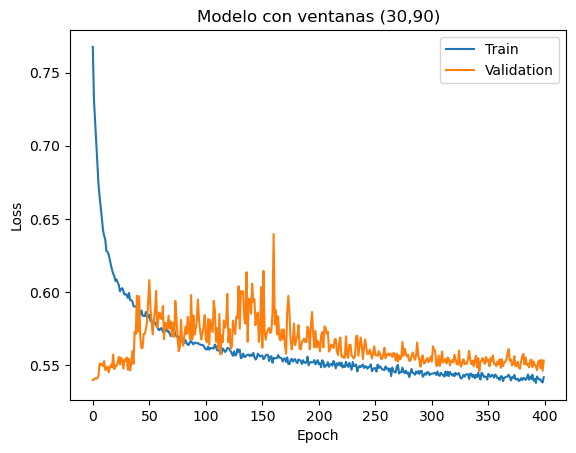

In [ ]:
plt.plot(hist_30_90.history['loss'])
plt.plot(hist_30_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo con ventanas (30,90)')
plt.show()

In [60]:
# 1. El modelo predice en escala normalizada usando los datos de test
#y_pred_nn_scaled_train_30_90 = model_30_90.predict(train_data_30_90)
#y_pred_nn_scaled_val_30_90 = model_30_90.predict(val_data_30_90)
#y_pred_nn_scaled_test_30_90 = model_30_90.predict(test_data_30_90)

y_pred_nn_scaled_train_30_90 = model_30_90.predict(X_train_flat_30_90)
y_pred_nn_scaled_val_30_90 = model_30_90.predict(X_val_flat_30_90)
y_pred_nn_scaled_test_30_90 = model_30_90.predict(X_test_flat_30_90)


# 2. Deshacemos la normalización usando el scaler de la llave (30,90)
scaler_y_30_90 = dicc_scaler[(30,90)]
y_pred_nn_real_train_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_train_30_90)
y_pred_nn_real_val_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_val_30_90)
y_pred_nn_real_test_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_test_30_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_90 = mean_absolute_error(dicc_target_train_purged[(30,90)], y_pred_nn_real_train_30_90)
mae_nn_val_30_90 = mean_absolute_error(dicc_target_val_purged[(30,90)], y_pred_nn_real_val_30_90)
mae_nn_test_30_90 = mean_absolute_error(dicc_target_test[(30,90)], y_pred_nn_real_test_30_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo (30,90)   =======')
print()
#print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_90:.6f}")
print()
#print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_90:.6f}")
print()
#print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_90:.6f}")
print()

347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo (30,90)   =======

MAE de la Red Neuronal (train):     0.000812

MAE de la Red Neuronal (val):     0.000933

MAE de la Red Neuronal (test):     0.001215



In [ ]:
# Guarda la arquitectura, los pesos y el estado del optimizador
#model_30_90.save('MODELOS/modelo_NN_30_90.keras')
model_30_90 = load_model('MODELOS/modelo_NN_30_90.keras')

### 6.2. Modelo con ventana de entrada de 90 días

In [12]:
train_data_90_90, train_target_90_90 = dicc_data_train_norm[(90,90)], dicc_target_train_norm[(90,90)]
val_data_90_90, val_target_90_90 = dicc_data_val_norm[(90,90)], dicc_target_val_norm[(90,90)]
test_data_90_90, test_target_90_90 = dicc_data_test_norm[(90,90)], dicc_target_test_norm[(90,90)]

In [17]:
num_samples_train_90_90 = train_data_90_90.shape[0]
num_samples_val_90_90 = val_data_90_90.shape[0]
num_samples_test_90_90 = test_data_90_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_90_90 = train_data_90_90.reshape(num_samples_train_90_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_90_90 = val_data_90_90.reshape(num_samples_val_90_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_90_90 = test_data_90_90.reshape(num_samples_test_90_90, -1)

In [69]:
# Modelo con 5 datos de entrada y uno de salida
model_90_90 = Sequential()
model_90_90.add(Dense(120, activation='relu', input_dim=(X_train_flat_90_90.shape[1])))
model_90_90.add(Dropout(0.4))
model_90_90.add(Dense(64, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
model_90_90.add(Dropout(0.3))
model_90_90.add(Dense(40, activation='relu'))
model_90_90.add(Dropout(0.3))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_90_90.add(Dense(train_target_90_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_90_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [73]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_90_90 = model_90_90.fit(X_train_flat_90_90, train_target_90_90, validation_data=(X_val_flat_90_90, val_target_90_90), epochs=150)

Epoch 1/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5689 - val_loss: 0.5495
Epoch 2/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.5690 - val_loss: 0.5486
Epoch 3/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5676 - val_loss: 0.5476
Epoch 4/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5702 - val_loss: 0.5496
Epoch 5/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5692 - val_loss: 0.5461
Epoch 6/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.5671 - val_loss: 0.5527
Epoch 7/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5667 - val_loss: 0.5516
Epoch 8/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.5667 - val_loss: 0.5536
Epoch 9/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.5691 - val_loss: 0.5506
Epoch 10/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.5661 - val_loss: 0.5502
Epoch 11/150
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5652 - val_loss: 0.5543
Epoch 12/150
345/345 ━━━━━━━━━━━━━━

In [71]:
aux_hist = hist_90_90
aux_model = model_90_90

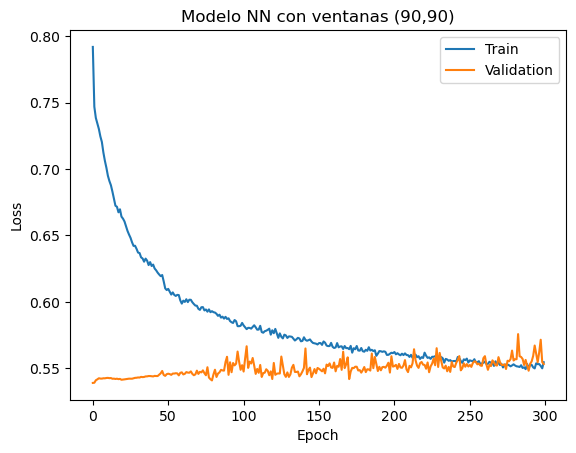

In [74]:
plt.plot(aux_hist.history['loss'] + hist_90_90.history['loss'])
plt.plot(aux_hist.history['val_loss'] + hist_90_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (90,90)')
plt.show()

In [76]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_90 = model_90_90.predict(X_train_flat_90_90)
y_pred_nn_scaled_val_90_90 = model_90_90.predict(X_val_flat_90_90)
y_pred_nn_scaled_test_90_90 = model_90_90.predict(X_test_flat_90_90)

# 2. Deshacemos la normalización usando el scaler de la llave (90,90)
scaler_y_90_90 = dicc_scaler[(90,90)]
y_pred_nn_real_train_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_train_90_90)
y_pred_nn_real_val_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_val_90_90)
y_pred_nn_real_test_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_test_90_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_90 = mean_absolute_error(dicc_target_train_purged[(90,90)], y_pred_nn_real_train_90_90)
mae_nn_val_90_90 = mean_absolute_error(dicc_target_val_purged[(90,90)], y_pred_nn_real_val_90_90)
mae_nn_test_90_90 = mean_absolute_error(dicc_target_test[(90,90)], y_pred_nn_real_test_90_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (90,90)   =======')
print()
#print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_90:.6f}")
print()
#print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_90:.6f}")
print()
#print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_90:.6f}")
print()

345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=======   Resultados modelo mixto (90,90)   =======

MAE de la Red Neuronal (train):     0.000840

MAE de la Red Neuronal (val):     0.000935

MAE de la Red Neuronal (test):     0.001143



In [77]:
# Guarda la arquitectura, los pesos y el estado del optimizador
model_90_90.save('MODELOS/modelo_NN_90_90.keras')
#model_90_90 = load_model('MODELOS/modelo_NN_90_90.keras')

## 7. Comparación de estrategias

Vamos a comparar una estrategia Buy & Hold de los 23 activos con una cartera equiponderada con una estrategia desarrollada a través de nuestros modelos. 

La idea es seleccionar en cada mes los cinco activos con una mejor predicción del retorno acumulado durante el siguiente periodo. La cartera se rebalanceará cada periodo (hay que definirlo). El objetivo es comprobar si nuestro modelo nos ayuda a seleccionar los activos de manera más óptima que la estrategia Buy & Hold. 

Supondremos comisiones constantes para reducir la complejidad.

### 7.1. Estrategia Buy & Hold

Obtenemos los retornos de 2025.

In [13]:
# Obtenemos los retornos de 2025
returns_2025 = returns.loc['2025-01-01':'2025-12-31']
print(f"Número de días a predecir: {returns_2025.shape}")
returns_2025.tail()

Número de días a predecir: (250, 23)


,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-24,0.001388,0.006023,0.002298,0.006039,-0.000066,0.011067,0.002099,0.005844,0.004498,0.003859,...,-0.002283,0.009672,0.003429,0.010062,0.001186,0.003907,0.013334,-0.005034,0.009108,-0.001676
2025-12-26,0.003117,-0.007915,-0.001303,0.002353,-0.003195,-0.008069,0.002017,-0.002313,-0.009279,-0.005096,...,0.013122,-0.000722,-0.003429,0.005072,0.010793,-0.005540,0.003095,0.001486,0.001729,-0.000923
2025-12-29,0.000864,0.003735,-0.007559,0.003389,0.006445,0.005532,0.004561,0.002414,-0.005039,-0.010218,...,-0.000752,-0.000337,0.004142,-0.008574,-0.002224,0.000347,-0.001500,0.000636,-0.001175,0.011851
2025-12-30,0.001899,0.005737,-0.002111,0.004933,0.008704,0.005241,0.001079,0.003510,-0.002971,0.000674,...,-0.003267,-0.003137,-0.001284,-0.000478,-0.003407,0.002600,-0.005266,0.017499,-0.003603,0.003809
2025-12-31,-0.005880,-0.006336,-0.007859,-0.007018,0.000656,-0.008926,-0.006183,-0.005723,-0.008312,-0.012133,...,-0.008595,0.000193,-0.002286,-0.003196,-0.006661,-0.001906,-0.007571,-0.001616,-0.005150,-0.005387


Calculamos el retorno diario de la cartera equiponderada para el año 2025 (estrategia Buy & Hold).

In [14]:
# Obtenemos los pesos de cada activo -> cartera equiponderada
num_activos = returns_2025.shape[1]
pesos = np.ones(num_activos)/num_activos

# Obtenemos los retornos diarios de la cartera
returns_diarios_BH = returns_2025 @ pesos
returns_diarios_BH

Date
2025-01-02   -0.002971
2025-01-03    0.004063
2025-01-06   -0.006587
2025-01-07    0.002155
2025-01-08    0.001458
                ...   
2025-12-24    0.004547
2025-12-26    0.000143
2025-12-29   -0.000687
2025-12-30    0.000946
2025-12-31   -0.007102
Length: 250, dtype: float64

Obtenemos la evolución de la rentabilidad obtenida durante el año 2025. Estos valores serán los que mostraremos en una gráfico y nos servirán para comparar estrategias.

In [15]:
capital_inicial = 1

# 1. Retorno logarítmico acumulado
retorno_log_acumulado = returns_diarios_BH.cumsum()

# 2. Conversión a factor de crecimiento (rentabilidad simple acumulada + 1)
factor_crecimiento = np.exp(retorno_log_acumulado)

# 3. Evolución del capital
valor_cartera_bh = capital_inicial * factor_crecimiento

# Visualizamos los primeros días
valor_cartera_bh.head()

Date
2025-01-02    0.997034
2025-01-03    1.001093
2025-01-06    0.994521
2025-01-07    0.996667
2025-01-08    0.998121
dtype: float64

La estrategia Buy & Hold acaba generando una rentabilidad del 13,73% anual y una volatilidad del 13,73% anual.

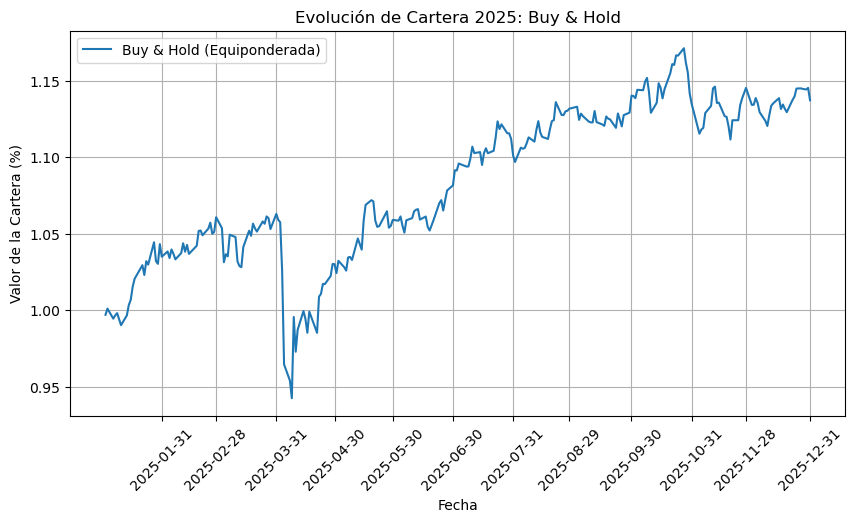

Rentabilidad Total 2025 (B&H): 13.73%
Volatilidad Anualizada (B&H):  13.73%


In [103]:
# Extraer el último día de cotización real de cada mes
valor_cartera_bh.index = pd.to_datetime(valor_cartera_bh.index)
ultimos_dias = valor_cartera_bh.groupby([valor_cartera_bh.index.year, valor_cartera_bh.index.month]).tail(1).index

# Forzar a matplotlib a usar solo esas fechas y darles un formato bonito (Ej: '2025-01-31')
fechas_formateadas = [fecha.strftime('%Y-%m-%d') for fecha in ultimos_dias]

# Gráfica de evolución
plt.figure(figsize=(10, 5))
plt.plot(valor_cartera_bh.index, valor_cartera_bh.values, label='Buy & Hold (Equiponderada)')
plt.title('Evolución de Cartera 2025: Buy & Hold')
plt.xlabel('Fecha')
plt.ylabel('Valor de la Cartera (%)')
plt.legend()
plt.xticks(ultimos_dias, fechas_formateadas, rotation=45)
plt.grid(True)
plt.show()

# 2. Métricas Clave
# Rentabilidad Total del Año
rentabilidad_total_bh = (valor_cartera_bh.iloc[-1] / capital_inicial) - 1
print(f"Rentabilidad Total 2025 (B&H): {rentabilidad_total_bh * 100:.2f}%")

# Volatilidad Anualizada (asumiendo 252 días de trading)
volatilidad_diaria = returns_diarios_BH.std()
volatilidad_anualizada_bh = volatilidad_diaria * np.sqrt(252)
print(f"Volatilidad Anualizada (B&H):  {volatilidad_anualizada_bh * 100:.2f}%")

### 7.2. Estrategia modelo (30,90)

Los datos que se generan en la función `create_time_series_data` los hacen seleccionando un vector de tantas posiciones como la ventana de entrada desde ese momento. Es decir, el primer valor del vector es el valor actual y el último es el que este a una distancia de la ventana de entrada al futuro. Por ello, debemos seleccionar los datos tantos días antes como la ventana de entrada, en este caso 30 días (observaciones).

In [69]:
# Selección de datos
indice_inicio = np.where(precios_close.index == '2024-12-02')[0][0] - 29
indice_final = np.where(precios_close.index == '2025-11-28')[0][0] - 29
indice_final_dataset = np.where(precios_close.index == precios_close.index[-1])[0][0]

# Índices clave para la selección de datos
indice_0 = indice_inicio - dicc_data[(30,90)].shape[0]   # Corresponde a precios_close.iloc[indice_inicio:indice_inicio+30]
indice_1 = indice_final - dicc_data[(30,90)].shape[0]    # Corresponde a precios_close.iloc[indice_final:indice_final+30]

# Los datos seleccionados son: dicc_data[(30,90)][indice_0:indice_1+1,:,0]

# Estos son los datos de 2025. Elegimos desde diciembre de 2024 para ver con que cartera entraríamos en 2025
X_30_90_2025 = dicc_data_test_norm[(30,90)][indice_0:indice_1+1]
y_30_90_2025 = dicc_target_test_norm[(30,90)][indice_0:indice_1+1]

Realizamos las transformaciones necesarias para que el formato de los datos sea el mismo que recibe el modelo entrenado. Obtenemos las predicciones en la escala estandarizada, por lo que tenemos que deshacer esa transformación para tenerlo en escala logarítmica (la original).

In [70]:
# Cargamos el modelo ya entrenado
model_30_90 = load_model('MODELOS/modelo_NN_30_90.keras')

# 1. El número de muestras es la PRIMERA dimensión de tus datos de ventana
num_samples_30_90_2025 = X_30_90_2025.shape[0]

# 2. Aplastamos los datos: (muestras, 30, 23) -> (muestras, 690)
X_flat_30_90_2025 = X_30_90_2025.reshape(num_samples_30_90_2025, -1)

# 3. Comprobación de seguridad (Debería imprimir: Muestras x 690)
print(f"Forma de los datos listos para predecir: {X_flat_30_90_2025.shape}")

# 4. Realizamos las predicciones
# Estos retornos están normalizados. Hay que deshacer la normalización para tenerlos en escala logarítmica
predicciones_retornos_30_90_2025 = model_30_90.predict(X_flat_30_90_2025)

# 5. Volvemos a escala logarítmica
scaler_y_30_90 = dicc_scaler[(30,90)]
prediccion_real_30_90_2025 = scaler_y_30_90.inverse_transform(predicciones_retornos_30_90_2025)

Forma de los datos listos para predecir: (249, 690)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


Como la estrategia es de rebalanceo mensual, seleccionamos para cada mes cuantos días hábiles hay para saber cuantos retornos acumulados hay que considerar en cada caso.

In [19]:
# 1. Filtramos tus datos reales (que ya contienen solo días hábiles)
datos_periodo = returns.loc['2024-12-02':'2025-11-28'].copy()
datos_periodo.index = pd.to_datetime(datos_periodo.index)

# 2. TRUCO CUANTITATIVO: Creamos un contador de sesiones (filas)
# El primer día será el 0, el segundo el 1, etc.
datos_periodo['sesion_bursatil'] = range(len(datos_periodo))

# 3. Extraemos la fila completa del último día de cada mes
ultimos_dias_df = datos_periodo.groupby([datos_periodo.index.year, datos_periodo.index.month]).tail(1)

# 4. Calculamos la diferencia usando nuestro contador de sesiones
# .diff() restará la fila actual menos la anterior (ej: sesión 42 - sesión 20 = 22 días hábiles)
dias_habiles_transcurridos = ultimos_dias_df['sesion_bursatil'].diff()

# 5. Creamos el DataFrame para visualizarlo
df_resultados = pd.DataFrame({
    'Último Día Bursátil': ultimos_dias_df.index.strftime('%Y-%m-%d'),
    'Días Hábiles Transcurridos': dias_habiles_transcurridos.values
})

# Para que el primer valor no salga como NaN, podemos poner un 0 o un texto
df_resultados['Días Hábiles Transcurridos'] = df_resultados['Días Hábiles Transcurridos'].fillna(0).astype(int)
df_resultados.iloc[0,1] = 20

dias_meses_30_90 = df_resultados['Días Hábiles Transcurridos'].values
dias_meses_30_90

#precios_close.iloc[indice_inicio+259:indice_inicio+278]

array([20, 20, 19, 21, 21, 21, 20, 22, 21, 21, 23, 19])

Obtenemos el vector de pesos para cada uno de los meses, ya que el rebalanceo es mensual. Observamos que el modelo nos indica invertir siempre en los mismos 5 activos.

In [21]:
num_dias = 0
lista_pesos_30_90 = []

for i in range(len(dias_meses_30_90)):
    #print(num_dias)
    dias = dias_meses_30_90[i]
    suma = np.sum(prediccion_real_30_90_2025[num_dias:num_dias + dias], axis = 0)
    mask = np.zeros_like(suma, dtype=float)
    top5 = np.argpartition(suma, -5)[-5:]
    mask[top5] = 0.2
    lista_pesos_30_90.append(mask)
    num_dias += dias

lista_pesos_30_90

[array([0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2]),
 array([0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2]),
 array([0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2]),
 array([0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2]),
 array([0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2]),
 array([0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2]),
 array([0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2]),
 array([0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0

En este caso nos fijamos que en todos los meses se seleccionan los mismos activos, por lo que la aplicación es la misma que en el apartado anterior. Es decir, es un caso particular de cartera equiponderada entre cinco activos. Estos cinco activos son: 

- **CVX** $\rightarrow$ Chevron Corporation
- **GD** $\rightarrow$ General Dynamics Corporation
- **IBM** $\rightarrow$ International Business Machines Corporation
- **MO** $\rightarrow$ Altria Group, Inc
- **XOM** $\rightarrow$ Exxon Mobil Corporation

In [23]:
# Los activos seleccionados siempre por este modelo son:
precios.columns[np.where(lista_pesos_30_90[0]*5 == 1)[0]]

Index(['CVX', 'GD', 'IBM', 'MO', 'XOM'], dtype='object')

Calculamos los retornos diarios de la estrategia de rebalanceo mensual según las predicciones del modelo con ventanas (30,90).

In [25]:
# Obtenemos los retornos diarios de la cartera
returns_diarios_30_90 = returns_2025 @ lista_pesos_30_90[0]
returns_diarios_30_90

Date
2025-01-02    1.130115e-03
2025-01-03    9.205230e-03
2025-01-06   -9.123627e-03
2025-01-07    5.010369e-03
2025-01-08   -1.612700e-03
                  ...     
2025-12-24    1.845394e-03
2025-12-26   -3.439604e-03
2025-12-29    3.146518e-03
2025-12-30    3.601916e-08
2025-12-31   -6.894469e-03
Length: 250, dtype: float64

Obtenemos la evolución de la rentabilidad obtenida durante el año 2025. Estos valores serán los que mostraremos en una gráfico y nos servirán para comparar estrategias.

In [26]:
capital_inicial = 1

# 1. Retorno logarítmico acumulado
retorno_log_acumulado_30_90 = returns_diarios_30_90.cumsum()

# 2. Conversión a factor de crecimiento (rentabilidad simple acumulada + 1)
factor_crecimiento_30_90 = np.exp(retorno_log_acumulado_30_90)

# 3. Evolución del capital
valor_cartera_30_90 = capital_inicial * factor_crecimiento_30_90

# Visualizamos los primeros días
valor_cartera_30_90.head()

Date
2025-01-02    1.001131
2025-01-03    1.010389
2025-01-06    1.001212
2025-01-07    1.006241
2025-01-08    1.004620
dtype: float64

La estrategia del modelo (30,90) con rebalanceo mensual acaba generando una rentabilidad del 22,15% anual y una volatilidad del 15,77% anual.

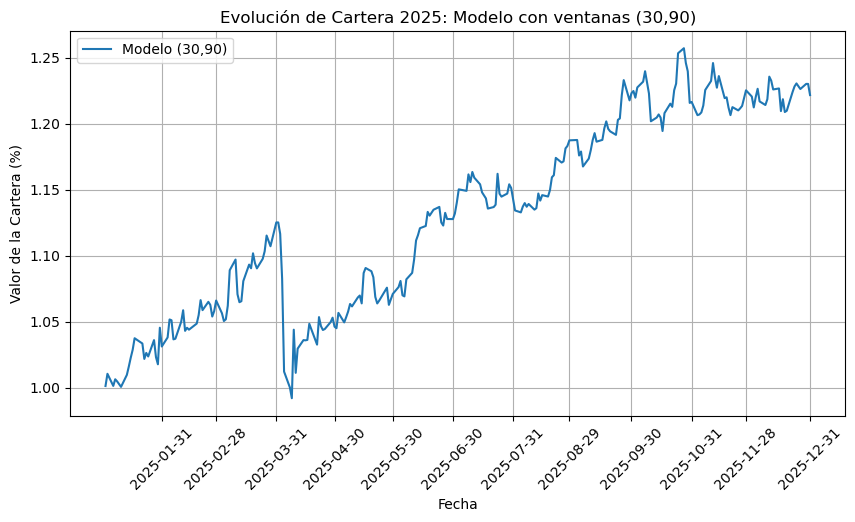

Rentabilidad Total 2025 (30,90): 22.15%
Volatilidad Anualizada (30,90):  15.77%


In [96]:
# Extraer el último día de cotización real de cada mes
valor_cartera_30_90.index = pd.to_datetime(valor_cartera_30_90.index)
ultimos_dias_30_90 = valor_cartera_30_90.groupby([valor_cartera_30_90.index.year, valor_cartera_30_90.index.month]).tail(1).index

# Forzar a matplotlib a usar solo esas fechas y darles un formato bonito (Ej: '2025-01-31')
fechas_formateadas_30_90 = [fecha.strftime('%Y-%m-%d') for fecha in ultimos_dias_30_90]

# Gráfica de evolución
plt.figure(figsize=(10, 5))
plt.plot(valor_cartera_30_90.index, valor_cartera_30_90.values, label='Modelo (30,90)')
plt.title('Evolución de Cartera 2025: Modelo con ventanas (30,90)')
plt.xlabel('Fecha')
plt.ylabel('Valor de la Cartera (%)')
plt.legend()
plt.xticks(ultimos_dias_30_90, fechas_formateadas_30_90, rotation=45)
plt.grid(True)
plt.show()

# 2. Métricas Clave
# Rentabilidad Total del Año
rentabilidad_total_30_90 = (valor_cartera_30_90.iloc[-1] / capital_inicial) - 1
print(f"Rentabilidad Total 2025 (30,90): {rentabilidad_total_30_90 * 100:.2f}%")

# Volatilidad Anualizada (asumiendo 252 días de trading)
volatilidad_anualizada_30_90 = returns_diarios_30_90.std() * np.sqrt(252)
print(f"Volatilidad Anualizada (30,90):  {volatilidad_anualizada_30_90 * 100:.2f}%")

### 7.3. Estrategia modelo (90,90)

Los datos que se generan en la función `create_time_series_data` los hacen seleccionando un vector de tantas posiciones como la ventana de entrada desde ese momento. Es decir, el primer valor del vector es el valor actual y el último es el que este a una distancia de la ventana de entrada al futuro. Por ello, debemos seleccionar los datos tantos días antes como la ventana de entrada, en este caso 90 días (observaciones).

In [65]:
# Selección de datos
indice_inicio_2 = np.where(precios_close.index == '2024-12-02')[0][0] - 89
indice_final_2 = np.where(precios_close.index == '2025-11-28')[0][0] - 89
indice_final_dataset_2 = np.where(precios_close.index == precios_close.index[-1])[0][0]

# Índices clave para la selección de datos
indice_0_2 = indice_inicio_2 - dicc_data[(90,90)].shape[0]   # Corresponde a precios_close.iloc[indice_inicio_2:indice_inicio_2+90]
indice_1_2 = indice_final_2 - dicc_data[(90,90)].shape[0]    # Corresponde a precios_close.iloc[indice_final_2:indice_final_2+90]

# Los datos seleccionados son: dicc_data[(90,90)][indice_0_2:indice_1_2+1,:,0]

# Estos son los datos de 2025. Elegimos desde diciembre de 2024 para ver con que cartera entraríamos en 2025
X_90_90_2025 = dicc_data_test_norm[(90,90)][indice_0_2:indice_1_2+1]
y_90_90_2025 = dicc_target_test_norm[(90,90)][indice_0_2:indice_1_2+1]

Realizamos las transformaciones necesarias para que el formato de los datos sea el mismo que recibe el modelo entrenado. Obtenemos las predicciones en la escala estandarizada, por lo que tenemos que deshacer esa transformación para tenerlo en escala logarítmica (la original).

In [71]:
# Cargamos el modelo ya entrenado
model_90_90 = load_model('MODELOS/modelo_NN_90_90.keras')

# 1. El número de muestras es la PRIMERA dimensión de tus datos de ventana
num_samples_90_90_2025 = X_90_90_2025.shape[0]

# 2. Aplastamos los datos: (muestras, 30, 23) -> (muestras, 690)
X_flat_90_90_2025 = X_90_90_2025.reshape(num_samples_90_90_2025, -1)

# 3. Comprobación de seguridad (Debería imprimir: Muestras x 690)
print(f"Forma de los datos listos para predecir: {X_flat_90_90_2025.shape}")

# 4. Realizamos las predicciones
# Estos retornos están normalizados. Hay que deshacer la normalización para tenerlos en escala logarítmica
predicciones_retornos_90_90_2025 = model_90_90.predict(X_flat_90_90_2025)

# 5. Volvemos a escala logarítmica
scaler_y_90_90 = dicc_scaler[(90,90)]
prediccion_real_90_90_2025 = scaler_y_90_90.inverse_transform(predicciones_retornos_90_90_2025)

Forma de los datos listos para predecir: (249, 2070)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


Como la estrategia es de rebalanceo cuatrimestral, seleccionamos para cada cuatrimestre cuantos días hábiles hay para saber cuantos retornos acumulados hay que considerar en cada caso.

In [104]:
# 1. Filtramos tus datos reales (que ya contienen solo días hábiles)
datos_periodo = returns.loc['2024-12-02':'2025-11-28'].copy()
datos_periodo.index = pd.to_datetime(datos_periodo.index)

# 2. TRUCO CUANTITATIVO: Creamos un contador de sesiones (filas)
# El primer día será el 0, el segundo el 1, etc.
datos_periodo['sesion_bursatil'] = range(len(datos_periodo))

# 3. Extraemos la fila completa del último día de cada mes
ultimos_dias_df = datos_periodo.groupby([datos_periodo.index.year, datos_periodo.index.month]).tail(1)

# 4. Calculamos la diferencia usando nuestro contador de sesiones
# .diff() restará la fila actual menos la anterior (ej: sesión 42 - sesión 20 = 22 días hábiles)
dias_habiles_transcurridos = ultimos_dias_df['sesion_bursatil'].diff()

# 5. Creamos el DataFrame para visualizarlo
df_resultados = pd.DataFrame({
    'Último Día Bursátil': ultimos_dias_df.index.strftime('%Y-%m-%d'),
    'Días Hábiles Transcurridos': dias_habiles_transcurridos.values
})

# Para que el primer valor no salga como NaN, podemos poner un 0 o un texto
df_resultados['Días Hábiles Transcurridos'] = df_resultados['Días Hábiles Transcurridos'].fillna(0).astype(int)
df_resultados.iloc[0,1] = 20

dias_meses_90_90 = []
for i in range(int(df_resultados.shape[0]/3)):
    suma = np.sum(df_resultados.iloc[4*i:4*(i+1)])
    dias_meses_90_90.append(suma[1])

dias_meses_90_90 = np.array(dias_meses_90_90[:-1])

#dias_meses_90_90 = df_resultados['Días Hábiles Transcurridos'].values
dias_meses_90_90

#precios_close.iloc[indice_inicio+259:indice_inicio+278]

array([80, 84, 84])

Obtenemos el vector de pesos para cada uno de los meses, ya que el rebalanceo es mensual. Observamos que el modelo nos indica invertir siempre en los mismos 5 activos.

In [105]:
num_dias = 0
lista_pesos_90_90 = []

for i in range(len(dias_meses_90_90)):
    #print(num_dias)
    dias = dias_meses_30_90[i]
    suma = np.sum(prediccion_real_90_90_2025[num_dias:num_dias + dias], axis = 0)
    mask = np.zeros_like(suma, dtype=float)
    top5 = np.argpartition(suma, -5)[-5:]
    mask[top5] = 0.2
    lista_pesos_90_90.append(mask)
    num_dias += dias

lista_pesos_90_90

[array([0. , 0. , 0.2, 0. , 0. , 0.2, 0. , 0. , 0. , 0. , 0. , 0.2, 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0. ]),
 array([0. , 0. , 0.2, 0. , 0. , 0.2, 0. , 0. , 0. , 0. , 0. , 0.2, 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0. ]),
 array([0. , 0. , 0.2, 0. , 0. , 0.2, 0. , 0. , 0. , 0. , 0. , 0.2, 0.2,
        0. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. , 0. , 0. ])]

En este caso nos fijamos que en todos los meses se seleccionan los mismos activos, por lo que la aplicación es la misma que en el apartado anterior. Es decir, es un caso particular de cartera equiponderada entre cinco activos. Estos cinco activos son: 

- **CAT** $\rightarrow$ Caterpillar
- **DIS** $\rightarrow$ The Walt Disney Company
- **HPQ** $\rightarrow$ HP Inc
- **IBM** $\rightarrow$ International Business Machines Corporation
- **MO** $\rightarrow$ Altria Group, Inc

In [76]:
# Los activos seleccionados siempre por este modelo son:
precios.columns[np.where(lista_pesos_90_90[0]*5 == 1)[0]]

Index(['CAT', 'DIS', 'HPQ', 'IBM', 'MO'], dtype='object')

Calculamos los retornos diarios de la estrategia de rebalanceo cuatrimestral según las predicciones del modelo con ventanas (90,90).

In [83]:
# Obtenemos los retornos diarios de la cartera
returns_diarios_90_90 = returns_2025 @ lista_pesos_90_90[0]
returns_diarios_90_90

Date
2025-01-02   -0.002653
2025-01-03    0.011754
2025-01-06    0.000412
2025-01-07   -0.002511
2025-01-08   -0.005907
                ...   
2025-12-24    0.005963
2025-12-26   -0.001773
2025-12-29   -0.004520
2025-12-30    0.000208
2025-12-31   -0.013132
Length: 250, dtype: float64

Obtenemos la evolución de la rentabilidad obtenida durante el año 2025. Estos valores serán los que mostraremos en una gráfico y nos servirán para comparar estrategias.

In [78]:
capital_inicial = 1

# 1. Retorno logarítmico acumulado
retorno_log_acumulado_90_90 = returns_diarios_90_90.cumsum()

# 2. Conversión a factor de crecimiento (rentabilidad simple acumulada + 1)
factor_crecimiento_90_90 = np.exp(retorno_log_acumulado_90_90)

# 3. Evolución del capital
valor_cartera_90_90 = capital_inicial * factor_crecimiento_90_90

# Visualizamos los primeros días
valor_cartera_90_90.head()

Date
2025-01-02    0.997351
2025-01-03    1.009143
2025-01-06    1.009559
2025-01-07    1.007026
2025-01-08    1.001095
dtype: float64

La estrategia del modelo (90,90) con rebalanceo cuatrimestral acaba generando una rentabilidad del 14,04% anual y una volatilidad del 19,46% anual.

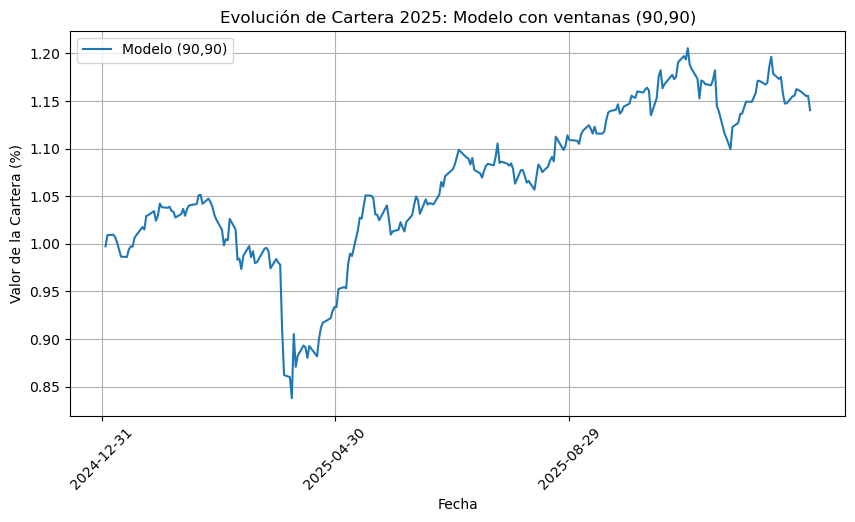

Rentabilidad Total 2025 (90,90): 14.04%
Volatilidad Anualizada (90,90):  19.46%


In [95]:
# Extraer el último día de cotización real de cada mes
valor_cartera_90_90.index = pd.to_datetime(valor_cartera_90_90.index)
ultimos_dias_90_90 = valor_cartera_90_90.groupby([valor_cartera_90_90.index.year, valor_cartera_90_90.index.month]).tail(1).index

# Forzar a matplotlib a usar solo esas fechas y darles un formato bonito (Ej: '2025-01-31')
fechas_formateadas_90_90 = [fecha.strftime('%Y-%m-%d') for fecha in ultimos_dias_df.index[:-1]]

# Gráfica de evolución
plt.figure(figsize=(10, 5))
plt.plot(valor_cartera_90_90.index, valor_cartera_90_90.values, label='Modelo (90,90)')
plt.title('Evolución de Cartera 2025: Modelo con ventanas (90,90)')
plt.xlabel('Fecha')
plt.ylabel('Valor de la Cartera (%)')
plt.legend()
plt.xticks(ultimos_dias_df.index[:-1], fechas_formateadas_90_90, rotation=45)
plt.grid(True)
plt.show()

# 2. Métricas Clave
# Rentabilidad Total del Año
rentabilidad_total_90_90 = (valor_cartera_90_90.iloc[-1] / capital_inicial) - 1
print(f"Rentabilidad Total 2025 (90,90): {rentabilidad_total_90_90 * 100:.2f}%")

# Volatilidad Anualizada (asumiendo 252 días de trading)
volatilidad_anualizada_90_90 = returns_diarios_90_90.std() * np.sqrt(252)
print(f"Volatilidad Anualizada (90,90):  {volatilidad_anualizada_90_90 * 100:.2f}%")

## 8. Resultados finales y conclusiones

En el siguiente gráfico se muestra la evolución de las carteras en el año 2025. Es preciso recordar que los modelos (30,90) y (90,90) se entrenaron desde 1967 hasta 2011.

Los resultados son los siguientes:

- **Estrategia Buy & Hold**: La rentabilidad anual obtenida es del 13,73%, su volatilidad anual es del 13,73% haciendo que su ratio de sharpe sea 1.
- **Estrategia modelo (30,90) con rebalanceo mensual**: La rentabilidad anual obtenida es del 22,15%, su volatilidad anual es del 15,77% haciendo que su ratio de sharpe sea 1,41.
- **Estrategia modelo (90,90) con rebalanceo cuatrimestral**: La rentabilidad anual obtenida es del 14,04%, su volatilidad anual es del 19,46% haciendo que su ratio de sharpe sea 0.72.

Por lo tanto, **la estrategia ganadora ha sido la del modelo (30,90) con rebalanceo mensual**.

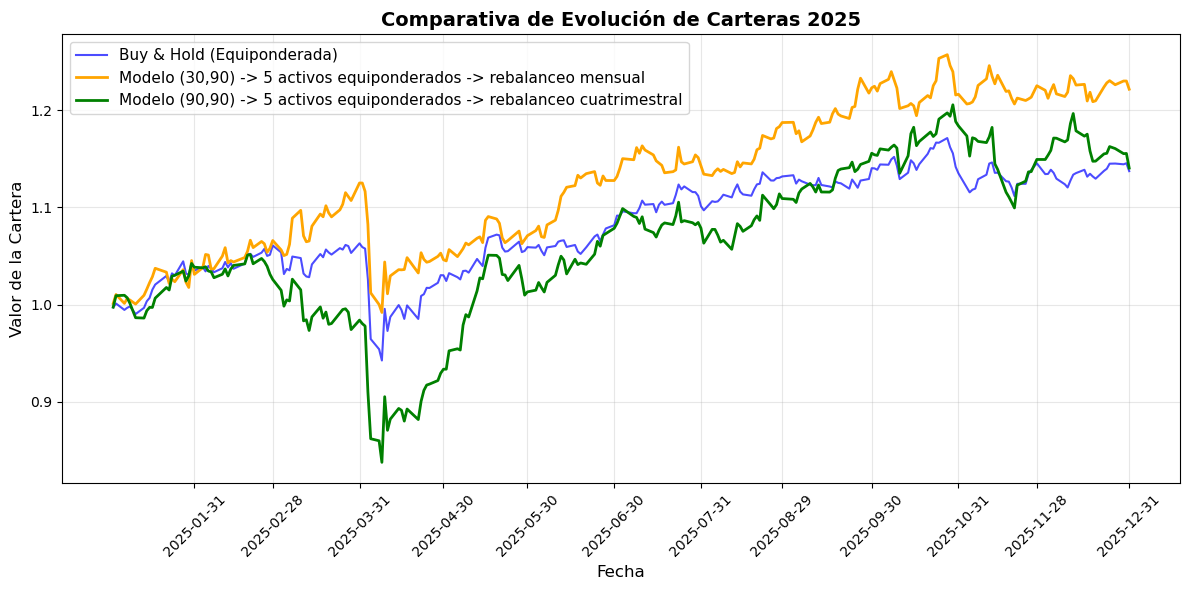

====== RENTABILIDAD TOTAL 2025 ======
Buy & Hold:      13.73%
Modelo (30,90):  22.15%
Modelo (90,90):  14.04%

====== VOLATILIDAD ANUALIZADA ======
Buy & Hold:      13.73%
Modelo (30,90):  15.77%
Modelo (90,90):  19.46%

====== RATIO DE SHARPE ======
Buy & Hold:      1.00
Modelo (30,90):  1.41
Modelo (90,90):  0.72


In [120]:
# 1. Asegurarnos de que los índices son Datetime
valor_cartera_bh.index = pd.to_datetime(valor_cartera_bh.index)
valor_cartera_30_90.index = pd.to_datetime(valor_cartera_30_90.index)
valor_cartera_90_90.index = pd.to_datetime(valor_cartera_90_90.index)

# 2. Extraer los últimos días de cada mes para el eje X
# Como las 3 carteras operan en 2025, basta con calcular los días usando una de ellas (ej. B&H)
ultimos_dias = valor_cartera_bh.groupby([valor_cartera_bh.index.year, valor_cartera_bh.index.month]).tail(1).index
fechas_formateadas = [fecha.strftime('%Y-%m-%d') for fecha in ultimos_dias]

# 3. Crear la figura unificada
plt.figure(figsize=(12, 6))

# Graficar las tres estrategias con colores y etiquetas distintas
plt.plot(valor_cartera_bh.index, valor_cartera_bh.values, label='Buy & Hold (Equiponderada)', color='blue', linewidth=1.5, alpha=0.7)
plt.plot(valor_cartera_30_90.index, valor_cartera_30_90.values, label='Modelo (30,90) -> 5 activos equiponderados -> rebalanceo mensual', color='orange', linewidth=2)
plt.plot(valor_cartera_90_90.index, valor_cartera_90_90.values, label='Modelo (90,90) -> 5 activos equiponderados -> rebalanceo cuatrimestral', color='green', linewidth=2)

# Configurar títulos, ejes y estilo
plt.title('Comparativa de Evolución de Carteras 2025', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Valor de la Cartera', fontsize=12)
plt.xticks(ultimos_dias, fechas_formateadas, rotation=45)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

# ==========================================
# 4. Imprimir Reporte de Métricas Clave
# ==========================================
print("====== RENTABILIDAD TOTAL 2025 ======")
rentabilidad_total_bh = (valor_cartera_bh.iloc[-1] / capital_inicial) - 1
print(f"Buy & Hold:      {rentabilidad_total_bh * 100:.2f}%")

rentabilidad_total_30_90 = (valor_cartera_30_90.iloc[-1] / capital_inicial) - 1
print(f"Modelo (30,90):  {rentabilidad_total_30_90 * 100:.2f}%")

rentabilidad_total_90_90 = (valor_cartera_90_90.iloc[-1] / capital_inicial) - 1
print(f"Modelo (90,90):  {rentabilidad_total_90_90 * 100:.2f}%")

print("\n====== VOLATILIDAD ANUALIZADA ======")
volatilidad_anualizada_bh = returns_diarios_BH.std() * np.sqrt(252)
print(f"Buy & Hold:      {volatilidad_anualizada_bh * 100:.2f}%")

# ¡Asegúrate de que estas variables se llamen igual en tu notebook!
volatilidad_anualizada_30_90 = returns_diarios_30_90.std() * np.sqrt(252) 
print(f"Modelo (30,90):  {volatilidad_anualizada_30_90 * 100:.2f}%")

volatilidad_anualizada_90_90 = returns_diarios_90_90.std() * np.sqrt(252)
print(f"Modelo (90,90):  {volatilidad_anualizada_90_90 * 100:.2f}%")

print("\n====== RATIO DE SHARPE ======")
print(f"Buy & Hold:      {rentabilidad_total_bh/volatilidad_anualizada_bh:.2f}")
 
print(f"Modelo (30,90):  {rentabilidad_total_30_90/volatilidad_anualizada_30_90:.2f}")

print(f"Modelo (90,90):  {rentabilidad_total_90_90/volatilidad_anualizada_90_90:.2f}")